# 04 · Gold standards and the nonlinear transfer

Everything so far lived on a bench with closed forms. Real inference problems
are not this polite, so the last act removes the politeness while keeping the
control. The prior stays the same Gaussian field g. The observation becomes
nonlinear:

$$y = A\,\kappa(g) + \text{noise}, \qquad
\kappa(g) = \left(e^{\lambda g - \lambda^2/2} - 1\right)/\lambda .$$

In words: we observe a smoothed version of an exponentially warped field, the
kind of lopsided (lognormal) field that nonlinear structure formation
produces. The dial lambda sets the warp strength. At lambda equal to zero the
problem collapses back to the exact bench, and that limit is the built-in
correctness test for everything here.

**Gold standards.** On this substrate no formula gives the posterior, which is
exactly the situation practitioners face. The claim that proper validation is
too expensive was tested directly: a NUTS (Hamiltonian MCMC) gold standard
takes about 74 seconds per 64x64 configuration on one GPU, passes a
Gaussian-limit gate, an independent closed-form importance-sampling
cross-check, and a seed-independence gate, and the whole apparatus repeats at
128x128.

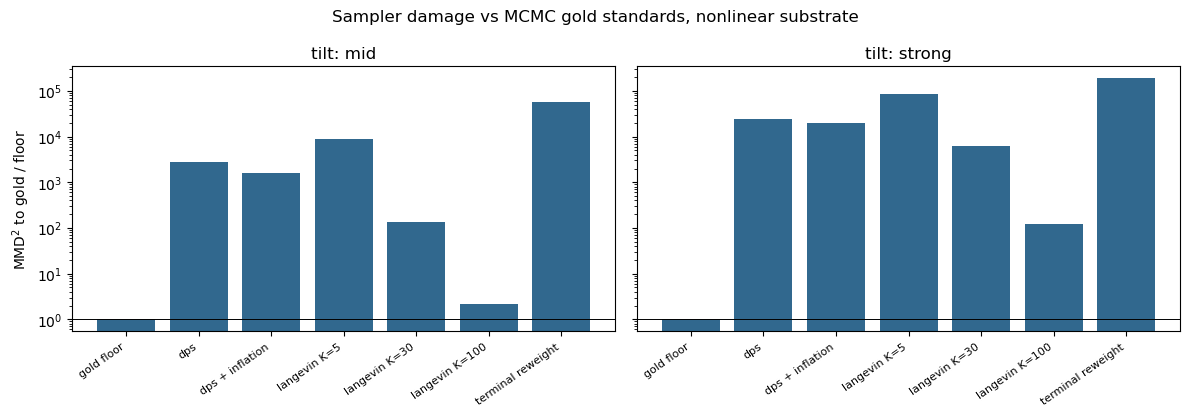

In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
RES = ROOT / "results"

def rows(name):
    p = RES / name
    if not p.exists():
        print(f"({name} not found, cell skipped)")
        return []
    return [json.loads(l) for l in p.open()]

tra = [r for r in rows("transfer.jsonl") if r.get("n") == 64
       and r.get("space") != "kappa_z" and abs(r.get("lam", 0) - 0.3143) < 1e-3]
by = defaultdict(list)
for r in tra:
    by[(r["tilt"], r["sampler"])].append(r["mmd2"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
order = ["gold_floor", "dps", "dps_inflated", "remy5", "remy30", "remy100",
         "terminal_is"]
disp = {"remy5": "langevin K=5", "remy30": "langevin K=30",
        "remy100": "langevin K=100", "dps_inflated": "dps + inflation",
        "gold_floor": "gold floor", "terminal_is": "terminal reweight"}
for ax, tiltname in zip(axes, ("mid", "strong")):
    floor = abs(np.median(by.get((tiltname, "gold_floor"), [1e-12])))
    labels, vals = [], []
    for s in order:
        v = by.get((tiltname, s))
        if v:
            labels.append(disp.get(s, s))
            vals.append(max(np.median(v), floor / 10) / floor)
    ax.bar(range(len(vals)), vals, color="#31688e")
    ax.set_yscale("log")
    ax.axhline(1, color="k", lw=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_title(f"tilt: {tiltname}")
axes[0].set_ylabel("MMD$^2$ to gold / floor")
fig.suptitle("Sampler damage vs MCMC gold standards, nonlinear substrate")
plt.tight_layout()
plt.show()

Two findings transfer, one breaks informatively. Plug-in guidance stays
overconfident (its fine-scale error bars cover the truth zero percent of the
time at strong steering). Annealed-Langevin refinement keeps buying accuracy
smoothly with compute, all the way to the gold standard. But the cheap
covariance correction that was mathematically exact on the Gaussian bench
decays to worthless as the warp grows:

In [2]:
lam_rows = [r for r in rows("transfer.jsonl") if r.get("n") == 64
            and r.get("tilt") == "mid" and r.get("yseed") == 0
            and r.get("space") != "kappa_z"]
byl = defaultdict(lambda: defaultdict(list))
for r in lam_rows:
    byl[round(r["lam"], 3)][r["sampler"]].append(r["mmd2"])
print("advantage of the inflated-covariance fix over plain plug-in guidance:")
print()
print("  warp (lam)   skewness   advantage")
for lam, skew in ((0.16, 0.5), (0.314, 1.0), (0.5, 2.0)):
    d = byl.get(lam, {})
    if "dps" in d and "dps_inflated" in d:
        adv = np.median(d["dps"]) / np.median(d["dps_inflated"])
        print(f"  {lam:8.3f}   {skew:8.1f}   {adv:6.1f}x")
print()
print("the correction's exactness was a Gaussian accident.")

advantage of the inflated-covariance fix over plain plug-in guidance:

  warp (lam)   skewness   advantage
     0.160        0.5     11.6x
     0.314        1.0      2.7x
     0.500        2.0      1.1x

the correction's exactness was a Gaussian accident.


## The last certificate standing, and its honest scope

One truth-free runtime check survived the audit in any form: run the sampler
at budget K and at 2K with fresh seeds, compare the two outputs with a
calibrated two-sample test, and treat agreement as convergence. The bench can
measure exactly what that certifies, because every run also gets compared to
the gold standard.

In [3]:
k2k = rows("k2k.jsonl")
byk = defaultdict(list)
for r in k2k:
    if r.get("arm") in ("remy", "dps"):
        key = (r["arm"], r["tilt"], r.get("K", r.get("T")))
        byk[key].append((r["agree"], r["mmd2_to_gold"]))
print("budget-doubling check vs the truth (strong tilt):")
print()
print("  sampler    budget   check says     truth says")
for (arm, tiltname, K), v in sorted(byk.items(), key=str):
    if tiltname != "strong":
        continue
    ag = np.mean([x[0] for x in v])
    m = np.median([x[1] for x in v])
    verdict = "converged" if ag >= 0.5 else "NOT converged"
    truth = "at gold floor" if m < 5e-3 else f"{m:.1e} from gold"
    print(f"  {arm:8s}   {K:6d}   {verdict:13s}  {truth}")
print()
nfe = rows("nfe2.jsonl")
if nfe:
    ags = np.mean([r["agree"] for r in nfe])
    m = np.median([r["mmd2_to_gold"] for r in nfe])
    fs = np.median([r["floor_scale"] for r in nfe])
    print(f"and for a deterministic-ODE (flow matching) sampler: agreement "
          f"{ags:.2f}\nat EVERY step count while sitting {m/fs:.0f}x above "
          f"the gold floor.")

budget-doubling check vs the truth (strong tilt):

  sampler    budget   check says     truth says
  dps           128   NOT converged  1.7e-01 from gold
  dps           256   converged      2.2e-01 from gold
  dps           512   converged      2.4e-01 from gold
  dps            64   NOT converged  1.9e-01 from gold
  remy           10   NOT converged  4.8e-01 from gold
  remy          100   converged      at gold floor
  remy           15   NOT converged  2.5e-01 from gold
  remy           25   NOT converged  7.4e-02 from gold
  remy           50   NOT converged  6.8e-03 from gold

and for a deterministic-ODE (flow matching) sampler: agreement 0.97
at EVERY step count while sitting 63x above the gold floor.


The pattern: for the annealed sampler at strong steering the check is
textbook, it flags every unconverged budget and passes the converged one. But
plug-in guidance converges confidently to the wrong answer and the check
co-signs it, two runs stuck on the same island agree, and for
deterministic-ODE samplers the alarm never fires at all. The honest scope is
one-directional. Disagreement proves non-convergence cheaply and with no
ground truth. Agreement proves nothing.

## What a practitioner should actually do

Offline, build a matched synthetic bench for your problem, manufacture MCMC
gold standards on it (minutes, not weeks, as measured above), and run your
actual sampler against them with sample-space tests. Measure how your
conclusions decay as the bench's realism dial turns, the way the covariance
correction was measured above. At runtime, use the doubling check for its
alarm and never for its silence.

The full story, told slowly with every construction explained, is the blog
post at [andreastersenov.github.io/tilt-audit](https://andreastersenov.github.io/tilt-audit/).
The prediction ledger with every pre-registered expectation and its score is
`RESEARCH_LOG.md`.